---
layout: post
title: Binary Representation of Real Numbers
excerpt: An introduction to binary representation of real numbers.
date: 2024-10-08
updatedDate: 2024-10-08
tags:
  - post
  - code
draft: true
---

In [Counting Ones Problem](/posts/counting-ones-problem) we explored a basic example of using bitstrings to represent candidate solutions to a problem, and we optimized our solution using a genetic algorithm. In this post we will see how to encode and decode real numbers using binary representation so we can apply these techniques to real-world problems.

### Encoding a Real Number
A real number is a number that can be expressed as a decimal. For example, 1.5 is a real number, as is 0.75. Real numbers are typically represented in binary as a floating-point number, which means part of the bitstring represents the significand (also called the mantissa) and the other part represents the exponent.

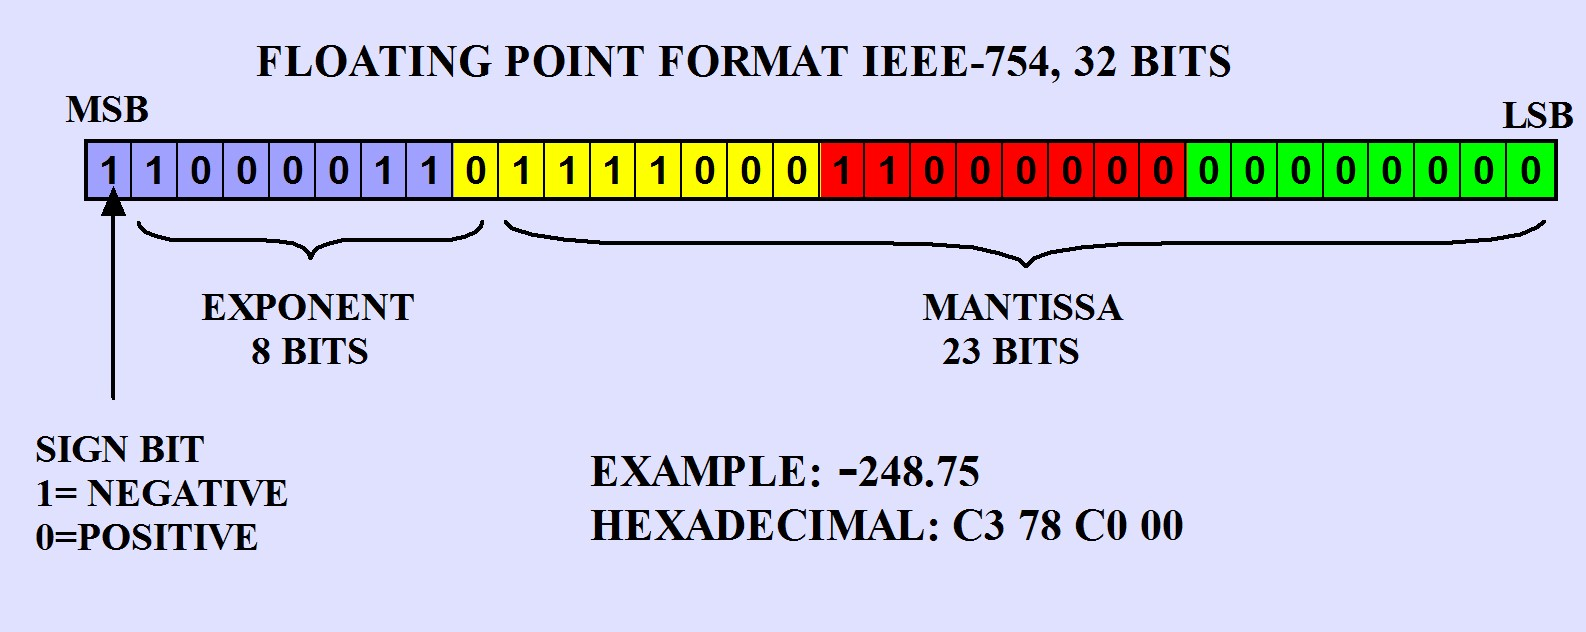
https://www.puntoflotante.net/IEEE-754-ENGLISH.jpg

If we know the bounds and the precision of the number we want to represent, we can create our own encoding scheme which is simpler and more space efficient.

Consider a simple case in which our values range from `4` to `8`, and we want to encode values to a precision of `0.1`. We can consider that there are buckets which span the range `[4, 8]` with a bucket size of `0.1`, and with some quick math we can see that there are `40` buckets in total. To encode 40 possible values, we need at least 6 bits. ($2^5 = 32$ would not be enough, and $2^6 = 64$ is more than enough.)

To formalize this approach, we can define the following:
- $a$ is the lower bound of our range
- $b$ is the upper bound of our range
- $\epsilon$ is the precision of our encoding
- $k$ is the number of bits we need to represent our encoding

We can calculate $k$ using the following equation:
$$
k = \lceil \log_2 \left( \frac{b - a}{2\epsilon} \right) \rceil
$$

Let's try this out with the values we defined above.

In [1]:
import numpy as np

In [2]:
a, b = 4, 8
epsilon = 0.1
k = int(np.ceil(np.log2((b - a)/(2*epsilon))))
print('k:\t\t', k)

k:		 5


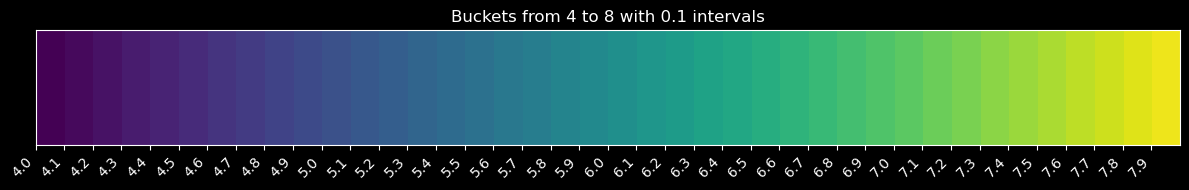

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

x = np.array(np.arange(a, b, epsilon).tolist() + [b])
fig, ax = plt.subplots(figsize=(12, 2))

cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=a, vmax=b)

heatmap = ax.imshow([norm(x)], cmap=cmap, aspect='auto', extent=[a, b + epsilon, 0, 1])

ticks = (x).tolist()[:-1]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{val:.1f}' for val in ticks], rotation=45, ha='right')
ax.set_xlim(a, b)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_title('Buckets from 4 to 8 with 0.1 intervals')
plt.tight_layout()

plt.show()



To confirm this is working as expected, let's try encoding many possible values and decoding them back to their original values.

In [ ]:
a, b = -1, 2
epsilon = 10**-6
r = 0.637197
expected_encoded_r = '1000101110110101000110'

In [ ]:
k = int(np.ceil(np.log2((b - a)/(2*epsilon))))

print('k:\t\t', k)
print('expected_k:\t', len(expected_encoded_r))

k:		 21
expected_k:	 22


In [ ]:
def enc(r: float) -> str:
    # Original equation: r_encoded = floor((r - a) / (b - a) * (2^k - 1) + 1/2)
    normalized_r = (r - a) / (b - a)
    scaled_r = normalized_r * (2**k - 1)
    rounded_r = int(scaled_r + 1/2)
    binary_representation = f"{rounded_r:b}"
    return binary_representation

def dec(encoded_r: str) -> float:
    # Original equation: a + int(encoded_r, 2) * (b-a)/(2**k - 1)
    encoded_int = int(encoded_r, 2)
    scaling_factor = (b - a) / (2**k - 1)
    scaled_value = encoded_int * scaling_factor
    decoded_r = a + scaled_value
    return decoded_r

In [ ]:
print('r:\t\t\t', r)
print('expected_encoded_r:\t', expected_encoded_r)
print()
print('encoded_r:\t\t', enc(r))
print('dec(encoded_r):\t\t', dec(enc(r)))
print('rounded dec(encoded_r):\t', round(dec(enc(r)), -int(np.floor(np.log10(epsilon)))))

r:			 0.637197
expected_encoded_r:	 1000101110110101000110

encoded_r:		 100010111011010100011
dec(encoded_r):		 0.637196844671652
rounded dec(encoded_r):	 0.637197


In [ ]:
for _ in range(100):
    r = np.random.uniform(a, b)
    assert abs(r - dec(enc(r))) < epsilon
